# Reading GRIN2B NWB Files

This notebook demonstrates how to read the converted GRIN2B NWB files from the Gonzalez-Sulser Lab. It covers:

1. Loading the NWB file and inspecting top-level metadata
2. Reading raw EEG/EMG acquisition data
3. Reading sleep-state epoch annotations
4. Reading seizure event intervals
5. Reading per-epoch spike-wave discharge (SWD) counts
6. Reading per-Zeitgeber-hour seizure totals
7. Reading per-sleep-state power spectra

**Prerequisites:** `pynwb`, `matplotlib`, `numpy`, `pandas`

```bash
conda activate gonzalez-sulser-lab-to-nwb-env
```

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pynwb import NWBHDF5IO

# Update this path to the location of your NWB file.
NWB_PATH = Path("H:/gonzalez-nwbfiles/GRIN2B_129/BL1.nwb")

## 1. Load and inspect top-level metadata

In [4]:
io = NWBHDF5IO(NWB_PATH, mode="r")
nwb = io.read()

print(f"Session ID:          {nwb.session_id}")
print(f"Session start time:  {nwb.session_start_time}")
print(f"Institution:         {nwb.institution}")
print(f"Lab:                 {nwb.lab}")
print(f"Subject ID:          {nwb.subject.subject_id}")
print(f"Subject species:     {nwb.subject.species}")
print()
print("Acquisition keys:", list(nwb.acquisition.keys()))
print("Processing modules:", list(nwb.processing.keys()))

Session ID:          BL1
Session start time:  2021-03-26 00:00:00+00:00
Institution:         University of Edinburgh
Lab:                 Gonzalez-Sulser Lab
Subject ID:          GRIN2B_129
Subject species:     Rattus norvegicus

Acquisition keys: ['EEGElectricalSeriesBL1', 'EMGElectricalSeriesBL1']
Processing modules: ['behavior', 'ecephys']


## 2. Raw EEG / EMG

The full 24 h recording is stored as **two** `ElectricalSeries` in `acquisition` — one for
EEG, one for EMG — sharing a single electrode table but linked to distinct `ElectrodeGroup`s:

- `EEGElectricalSeriesBL1`: **14 EEG channels** — bilateral cortex — S1_Tr, M2_Fra, M2_anterior, M1_anterior, V2_ML, V1_M, S1Hl_S1Fl (Right + Left)
- `EMGElectricalSeriesBL1`: **2 EMG channels** — Right and Left

ADC gain (conversion to Volts) is pending lab confirmation — data is stored in raw int16 counts.

In [5]:
eeg_es = nwb.acquisition["EEGElectricalSeriesBL1"]
emg_es = nwb.acquisition["EMGElectricalSeriesBL1"]

for name, es in [("EEG", eeg_es), ("EMG", emg_es)]:
    print(f"--- {name} ---")
    print(f"ElectricalSeries shape:  {es.data.shape}")
    print(f"Sampling rate:           {es.rate} Hz")
    print(f"Starting time:           {es.starting_time:.2f} s (offset from session_start_time)")
    print(f"Duration:                {es.data.shape[0] / es.rate / 3600:.2f} h")
    print()

electrodes = nwb.electrodes.to_dataframe()
print(electrodes.to_string())

--- EEG ---
ElectricalSeries shape:  (21634560, 14)
Sampling rate:           250.4 Hz
Starting time:           72240.00 s (offset from session_start_time)
Duration:                24.00 h

--- EMG ---
ElectricalSeries shape:  (21634560, 2)
Sampling rate:           250.4 Hz
Starting time:           72240.00 s (offset from session_start_time)
Duration:                24.00 h

       location                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

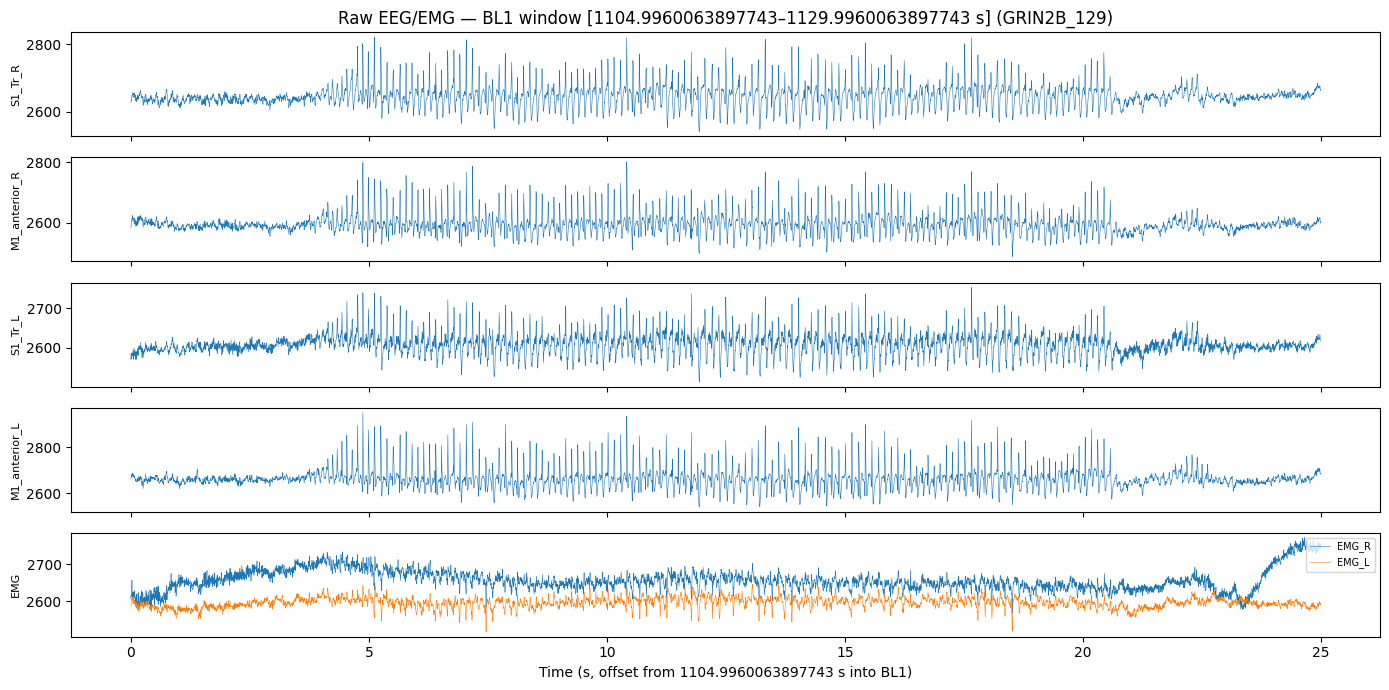

In [6]:
# ── Time window (seconds relative to the start of the BL window) ──────────────
window_start_s = (
    73350 - eeg_es.starting_time - 5
)  # start of the plot window (s from BL start)
window_end_s   = None      # end of the plot window   (s from BL start)
# Alternatively, set a duration and leave window_end_s = None:
window_duration_s = 25  # e.g. 60  — overrides window_end_s when not None
# ──────────────────────────────────────────────────────────────────────────────

fs = eeg_es.rate
if window_duration_s is not None:
    window_end_s = window_start_s + window_duration_s

i_start = int(window_start_s * fs)
i_end   = int(window_end_s   * fs)
t = np.arange(i_start, i_end) / fs - window_start_s  # t=0 at window_start_s

eeg_slice = eeg_es.data[i_start:i_end, :]  # lazy HDF5 read
emg_slice = emg_es.data[i_start:i_end, :]  # lazy HDF5 read

# EEG channels: indices within EEGElectricalSeriesBL1 (14 channels) — pick a bilateral pair
eeg_idx = {"S1_Tr_R": 0, "M1_anterior_R": 3, "S1_Tr_L": 13, "M1_anterior_L": 10}
# EMG channels: indices within EMGElectricalSeriesBL1 (2 channels)
emg_idx = {"EMG_R": 0, "EMG_L": 1}

fig, axes = plt.subplots(len(eeg_idx) + 1, 1, figsize=(14, 7), sharex=True)

for ax, (label, idx) in zip(axes[:-1], eeg_idx.items()):
    ax.plot(t, eeg_slice[:, idx], lw=0.4)
    ax.set_ylabel(label, fontsize=8)

ax_emg = axes[-1]
for label, idx in emg_idx.items():
    ax_emg.plot(t, emg_slice[:, idx], lw=0.4, label=label)
ax_emg.set_ylabel("EMG", fontsize=8)
ax_emg.legend(fontsize=7, loc="upper right")
ax_emg.set_xlabel(f"Time (s, offset from {window_start_s} s into BL1)")

axes[0].set_title(
    f"Raw EEG/EMG — BL1 window [{window_start_s}–{window_end_s} s] (GRIN2B_129)"
)
plt.tight_layout()
plt.show()

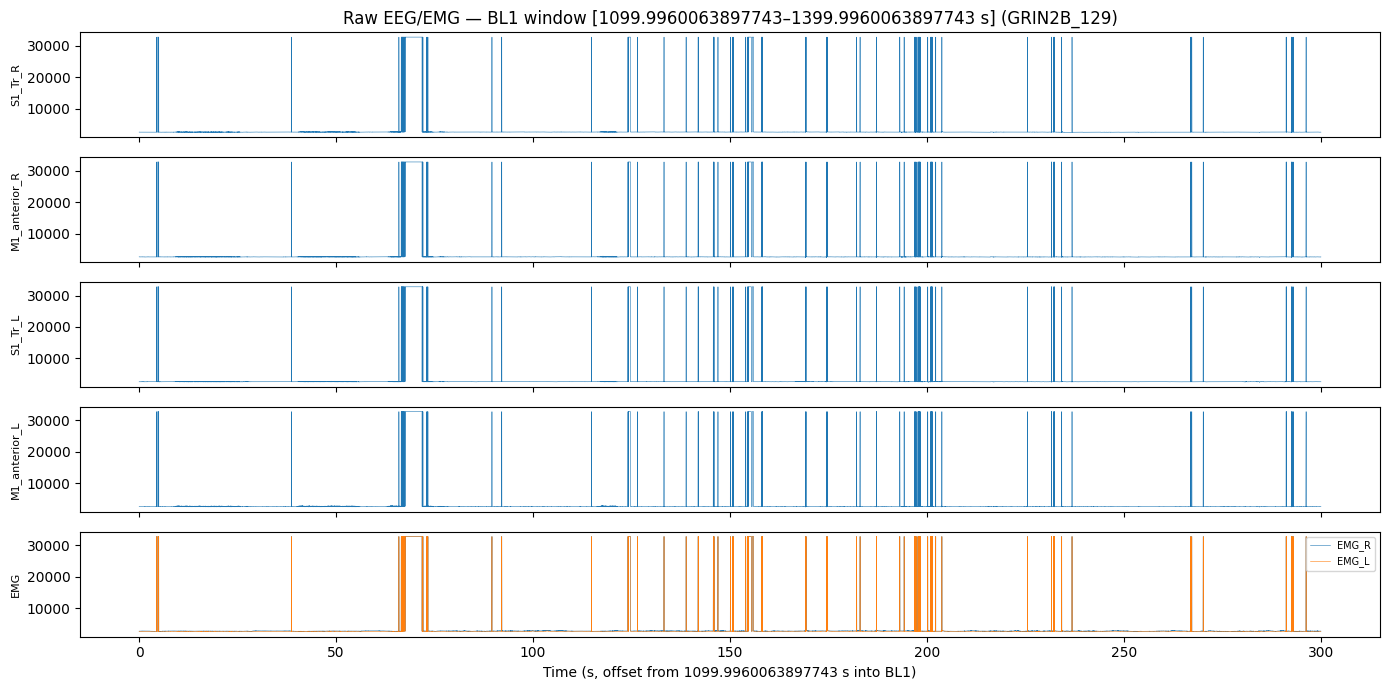

In [7]:
# ── Time window (seconds relative to the start of the BL window) ──────────────
window_start_s = (
    73350 - eeg_es.starting_time - 10
)  # start of the plot window (s from BL start)
window_end_s   = None      # end of the plot window   (s from BL start)
# Alternatively, set a duration and leave window_end_s = None:
window_duration_s = 300  # e.g. 60  — overrides window_end_s when not None
# ──────────────────────────────────────────────────────────────────────────────

fs = eeg_es.rate
if window_duration_s is not None:
    window_end_s = window_start_s + window_duration_s

i_start = int(window_start_s * fs)
i_end   = int(window_end_s   * fs)
t = np.arange(i_start, i_end) / fs - window_start_s  # t=0 at window_start_s

eeg_slice = eeg_es.data[i_start:i_end, :]  # lazy HDF5 read
emg_slice = emg_es.data[i_start:i_end, :]  # lazy HDF5 read

# EEG channels: indices within EEGElectricalSeriesBL1 (14 channels) — pick a bilateral pair
eeg_idx = {"S1_Tr_R": 0, "M1_anterior_R": 3, "S1_Tr_L": 13, "M1_anterior_L": 10}
# EMG channels: indices within EMGElectricalSeriesBL1 (2 channels)
emg_idx = {"EMG_R": 0, "EMG_L": 1}

fig, axes = plt.subplots(len(eeg_idx) + 1, 1, figsize=(14, 7), sharex=True)

for ax, (label, idx) in zip(axes[:-1], eeg_idx.items()):
    ax.plot(t, eeg_slice[:, idx], lw=0.4)
    ax.set_ylabel(label, fontsize=8)

ax_emg = axes[-1]
for label, idx in emg_idx.items():
    ax_emg.plot(t, emg_slice[:, idx], lw=0.4, label=label)
ax_emg.set_ylabel("EMG", fontsize=8)
ax_emg.legend(fontsize=7, loc="upper right")
ax_emg.set_xlabel(f"Time (s, offset from {window_start_s} s into BL1)")

axes[0].set_title(
    f"Raw EEG/EMG — BL1 window [{window_start_s}–{window_end_s} s] (GRIN2B_129)"
)
plt.tight_layout()
plt.show()

## 3. Sleep-state epochs

5-second scored epochs in `processing/behavior/sleep_states`.  
State codes: 0 = Wake, 1 = NREM, 2 = REM (TODO: confirm with lab).

In [8]:
behavior = nwb.processing["behavior"]
sleep = behavior["sleep_states"]
sleep_df = sleep.to_dataframe()

print(f"Sleep epochs: {len(sleep_df)} rows (expected 17,280 for full 24 h)")
print(sleep_df.head(10).to_string())
print()
print("State counts:", sleep_df["sleep_score"].value_counts().sort_index().to_dict())

Sleep epochs: 17280 rows (expected 17,280 for full 24 h)
      start_time     stop_time  sleep_score sleep_state
id                                                     
0   72240.003994  72245.003994            0        Wake
1   72245.003994  72250.003994            0        Wake
2   72250.003994  72255.003994            0        Wake
3   72255.003994  72260.003994            0        Wake
4   72260.003994  72265.003994            0        Wake
5   72265.003994  72270.003994            0        Wake
6   72270.003994  72275.003994            0        Wake
7   72275.003994  72280.003994            0        Wake
8   72280.003994  72285.003994            0        Wake
9   72285.003994  72290.003994            0        Wake

State counts: {0: 10539, 1: 6443, 2: 298}


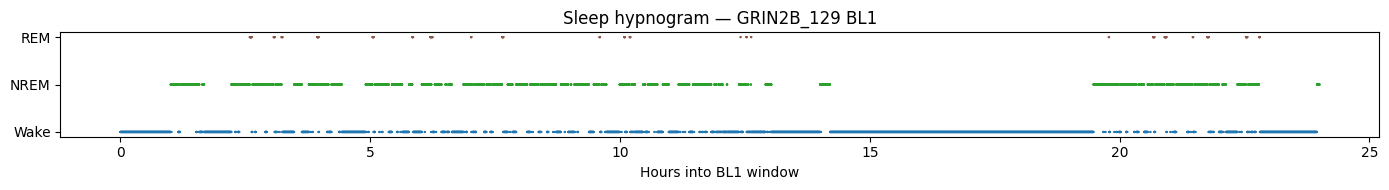

In [9]:
# Sleep hypnogram
state_labels = {0: "Wake", 1: "NREM", 2: "REM", 4: "Unknown"}
t_mid = (sleep_df["start_time"] + sleep_df["stop_time"]) / 2
hours = (t_mid - eeg_es.starting_time) / 3600  # hours into BL window

fig, ax = plt.subplots(figsize=(14, 2))
ax.scatter(hours, sleep_df["sleep_score"], s=0.3, c=sleep_df["sleep_score"],
           cmap="tab10", vmin=0, vmax=4)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Wake", "NREM", "REM"])
ax.set_xlabel("Hours into BL1 window")
ax.set_title("Sleep hypnogram — GRIN2B_129 BL1")
plt.tight_layout()
plt.show()

## 4. Seizure events

Stored as a `pynwb.epoch.TimeIntervals` table in `processing/behavior/seizure_events`.
The table has one row per seizure event, with `start_time`, `stop_time`, and `duration` columns.

N seizures:  753
Total seizure time:  3318.6 s
Mean duration:       4.41 s  (range: 0.8–21.2 s)


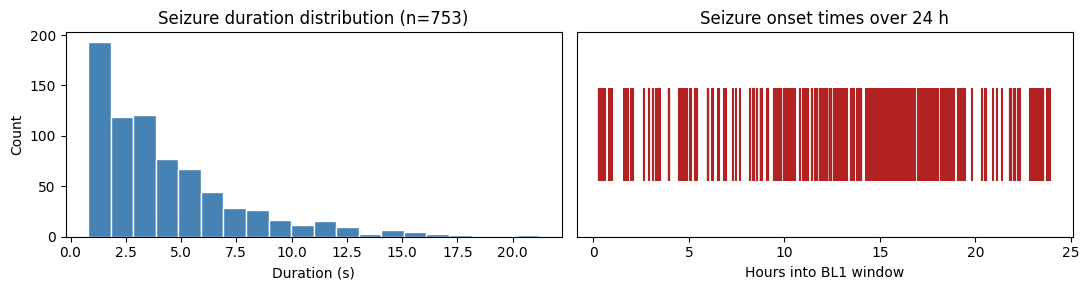

In [10]:
seizure_table = behavior["seizure_events"]
seizure_df = seizure_table.to_dataframe()

start_times = seizure_df["start_time"].to_numpy()
stop_times  = seizure_df["stop_time"].to_numpy()
durations   = seizure_df["duration"].to_numpy()

print(f"N seizures:  {len(start_times)}")
if len(durations) > 0:
    print(f"Total seizure time:  {durations.sum():.1f} s")
    print(f"Mean duration:       {durations.mean():.2f} s  (range: {durations.min():.1f}–{durations.max():.1f} s)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3))

    # Duration histogram
    axes[0].hist(durations, bins=20, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Duration (s)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Seizure duration distribution (n={len(durations)})")

    # Event timeline relative to BL window start
    bl_offset = eeg_es.starting_time
    rel_start = (start_times - bl_offset) / 3600
    axes[1].eventplot(rel_start, lineoffsets=0, linelengths=0.5, color="firebrick")
    axes[1].set_xlabel("Hours into BL1 window")
    axes[1].set_yticks([])
    axes[1].set_title("Seizure onset times over 24 h")

    plt.tight_layout()
    plt.show()
else:
    print("No seizure events in this window.")

## 5. Per-epoch SWD counts

`swd_epoch_counts` is a `TimeSeries` at 0.2 Hz (one value per 5-s sleep epoch).

SWD epochs: 17280 (expected 17,280 for full 24 h)
Non-zero epochs: 17280


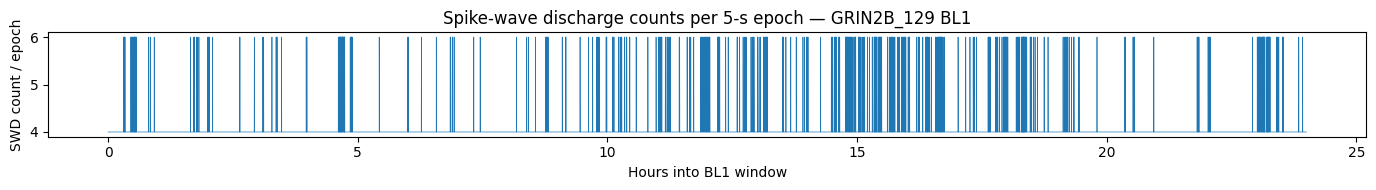

In [11]:
swd = behavior["swd_epoch_counts"]
swd_data = swd.data[:]
epoch_times = swd.starting_time + np.arange(len(swd_data)) / swd.rate
hours_swd = (epoch_times - eeg_es.starting_time) / 3600

print(f"SWD epochs: {len(swd_data)} (expected 17,280 for full 24 h)")
print(f"Non-zero epochs: {(swd_data > 0).sum()}")

fig, ax = plt.subplots(figsize=(14, 2))
ax.plot(hours_swd, swd_data, lw=0.5)
ax.set_xlabel("Hours into BL1 window")
ax.set_ylabel("SWD count / epoch")
ax.set_title("Spike-wave discharge counts per 5-s epoch — GRIN2B_129 BL1")
plt.tight_layout()
plt.show()

## 6. Per-sleep-state power spectra

628 frequency bins (0→125.2 Hz, 0.2 Hz steps = Nyquist of 250.4 Hz).  
States: s_0 = Wake, s_1 = NREM, s_2 = REM, s_4 = unknown (TODO: confirm with lab).

PSD table: (627, 5)
    frequency_hz       s_0       s_1       s_2       s_4
id                                                      
0            0.0  0.519809  0.539314  0.123515  0.634967
1            0.2  0.497687  0.535483  0.108808  0.614226
2            0.4  0.483442  0.558114  0.093001  0.598746
3            0.6  0.453522  0.574946  0.070813  0.554426
4            0.8  0.439977  0.590124  0.068346  0.537512


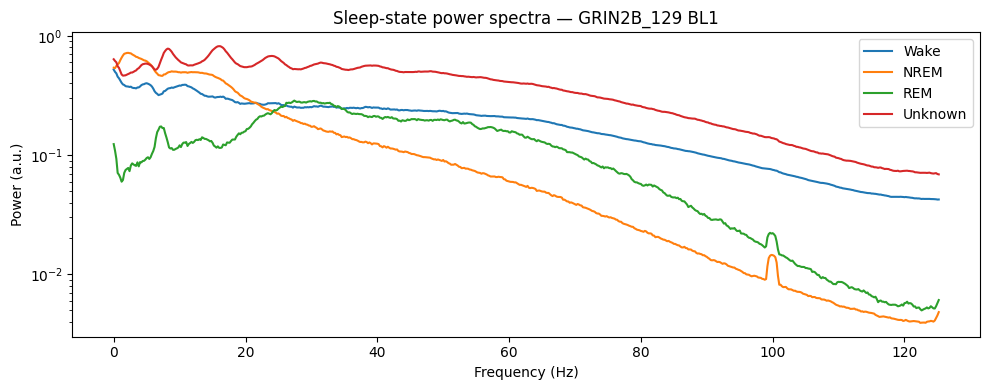

In [12]:
ecephys = nwb.processing["ecephys"]
psd_table = ecephys["sleep_state_power_spectra"]
psd_df = psd_table.to_dataframe()

print(f"PSD table: {psd_df.shape}")
print(psd_df.head())

fig, ax = plt.subplots(figsize=(10, 4))
state_cols = [c for c in psd_df.columns if c.startswith("s_")]
state_labels_psd = {"s_0": "Wake", "s_1": "NREM", "s_2": "REM", "s_4": "Unknown"}
for col in state_cols:
    ax.semilogy(
        psd_df["frequency_hz"], psd_df[col], label=state_labels_psd.get(col, col)
    )
# ax.set_xlim(0, 50)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (a.u.)")
ax.set_title("Sleep-state power spectra — GRIN2B_129 BL1")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Always close the file when done
io.close()